In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from helper_functions import *
from algorithms import *
import random
from pathlib import Path

In [3]:
BASE_DIR = './'
DIR_24   =  "./chromosomes"
IMG_24   =  f"{DIR_24}"
IMG_24 = Path('/Users/aning/Downloads/chromosomes')
SUBSET_SIZE = 100
all_img_24   = sorted(IMG_24.glob("*.jpg"))   + sorted(IMG_24.glob("*.JPG"))  

In [4]:
print(IMG_24)

/Users/aning/Downloads/chromosomes


In [5]:
img_24   = random.sample(all_img_24,   min(SUBSET_SIZE, len(all_img_24)))   if SUBSET_SIZE else all_img_24

/opt/anaconda3/lib/python3.13/site-packages/skimage/_shared/utils.py:445: UserWarning: This might be a color image. The histogram will be computed on the flattened image. You can instead apply this function to each color channel, or set channel_axis.
  return func(*args, **kwargs)


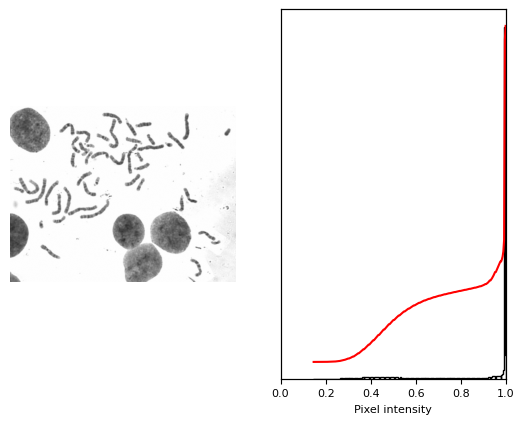

In [19]:
fig, ax_img, ax_hist, ax_cdf = plot_img_and_hist(img_24[0])

In [ ]:
img = skimage.io.imread(img_24[18])
mask = chromosome_mask_with_adaptive_histogram(img_24[56],closing_disk_size=4,   # reduce from 8
        opening_disk_size=9,   # reduce from 8
        min_distance=3,        # reduce to split closer chromosomes
        min_object_size=400, plot=True)

labels = label(mask)
print(f"Number of chromosomes detected: {labels.max()}")

In [ ]:
chromosome_data = []
for img_path in img_24[:10]:
    mask = chromosome_mask_with_adaptive_histogram(img_path, plot=False)
    labels = label(mask)
    chromosome_data.append({
        "img_name":img_path.name,
        "chromosome_count":labels.max(),
        "mask":mask,
        "needs_fix":labels.max()<40
    })


chromosome_data = pd.DataFrame(chromosome_data)

In [109]:
chromosome_data.head()

,img_name,chromosome_count,mask,needs_fix
0,104114.jpg,34,"[[False, False, False, False, False, False, Fa...",True
1,103143.jpg,34,"[[False, False, False, False, False, False, Fa...",True
2,1060892.jpg,32,"[[False, False, False, False, False, False, Fa...",True
3,1057704.jpg,34,"[[False, False, False, False, False, False, Fa...",True
4,1054831.jpg,24,"[[False, False, False, False, False, False, Fa...",True


In [130]:
records = []

for img_path in img_24[:10]:
    img_gray     = skimage.io.imread(img_path, as_gray=True)
    img_gray     = np.clip(img_gray, 0, 1)

    mask = chromosome_mask_with_adaptive_histogram(img_path, plot=False)
    labeled      = label(mask)
    regions      = regionprops(labeled)

    for region in regions:
        minr, minc, maxr, maxc = region.bbox
        pad  = 5
        minr = max(0, minr - pad)
        minc = max(0, minc - pad)
        maxr = min(mask.shape[0], maxr + pad)
        maxc = min(mask.shape[1], maxc + pad)

        chrom_mask = (labeled[minr:maxr, minc:maxc] == region.label)
        img_crop   = img_gray[minr:maxr, minc:maxc]

        chrom_img  = img_crop * chrom_mask

        records.append({
            "image_name":         img_path.name,
            "chromosome_label":   region.label,
            "chrom_img":          chrom_img,
            "method":             'adaptive_histogram',

            "area":               region.area,
            "length":             region.major_axis_length,   
            "width":              region.minor_axis_length,  
            "eccentricity":       region.eccentricity,  

            "centroid_row":       region.centroid[0],
            "centroid_col":       region.centroid[1],

            "orientation":        region.orientation,

            "bbox_minr":          region.bbox[0],
            "bbox_minc":          region.bbox[1],
            "bbox_maxr":          region.bbox[2],
            "bbox_maxc":          region.bbox[3],

            "number_of_chromosomes": labeled.max()
        })


df = pd.DataFrame(records)

KeyboardInterrupt: 

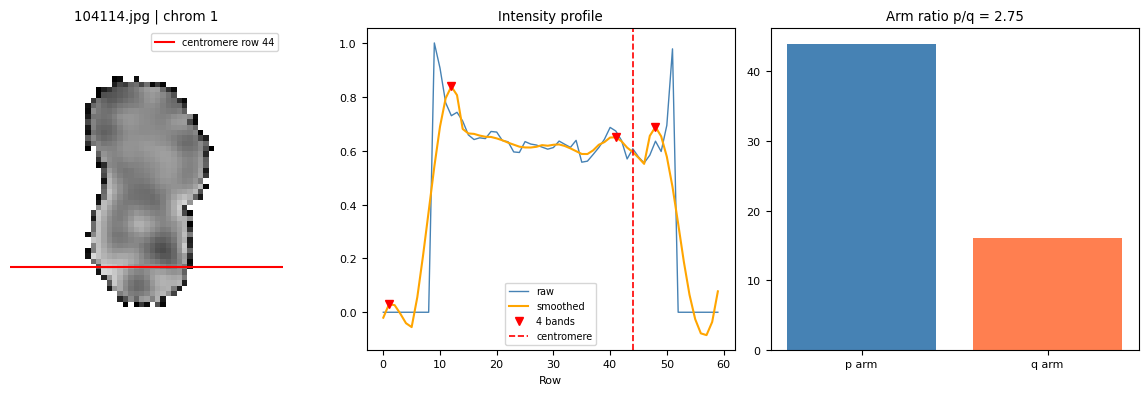

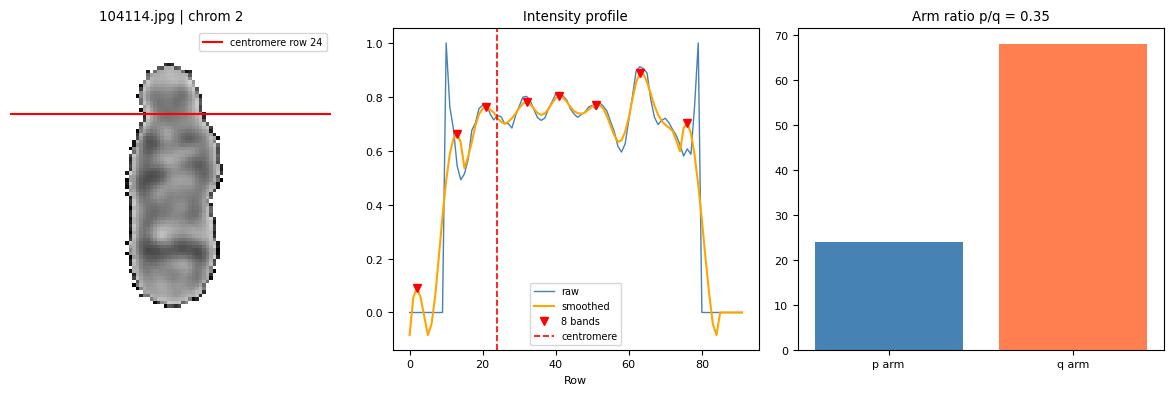

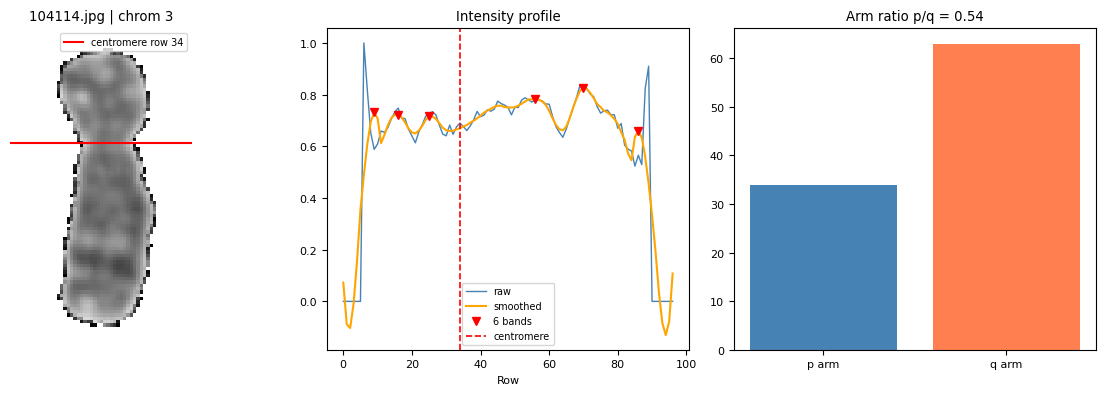

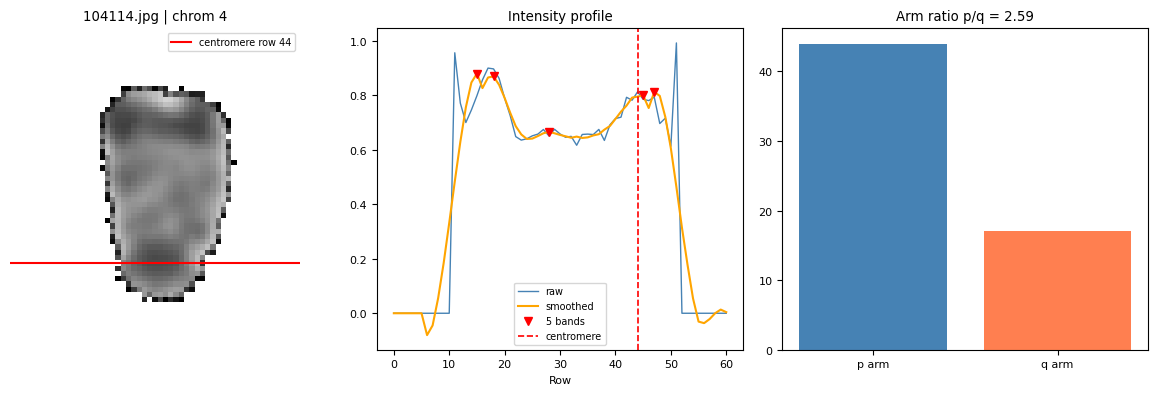

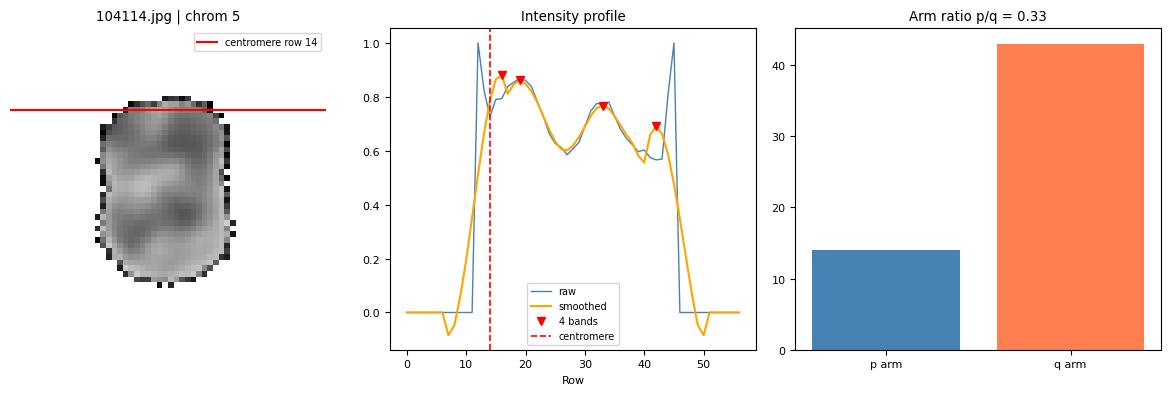

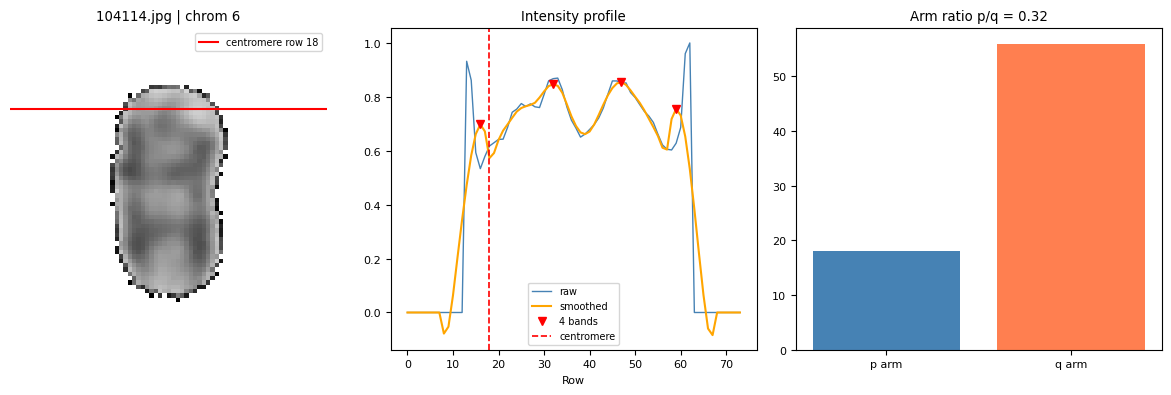

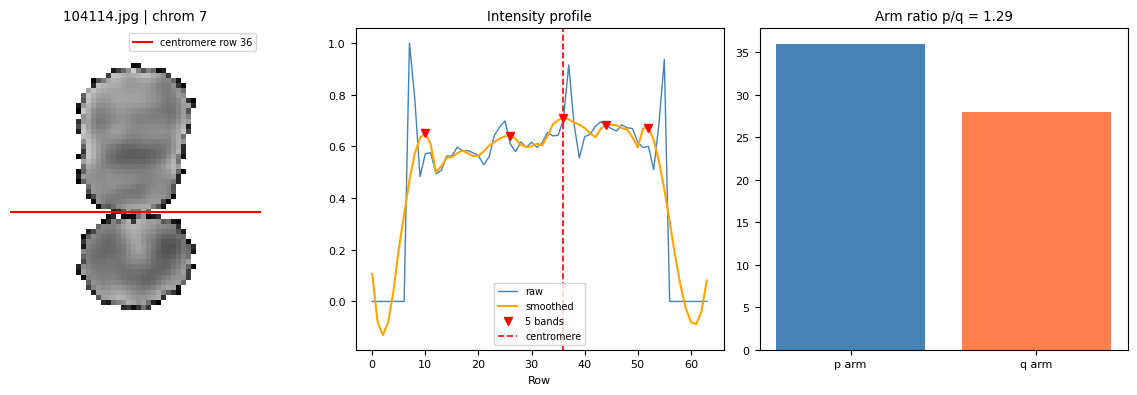

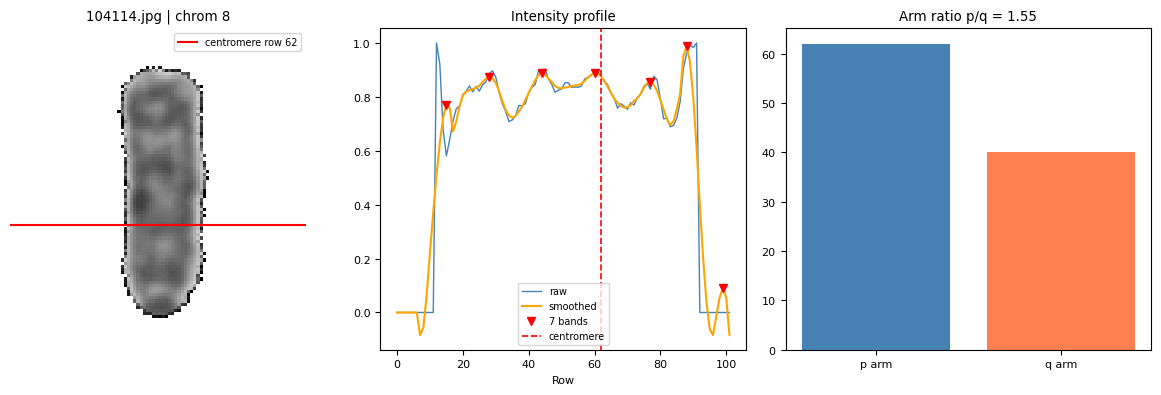

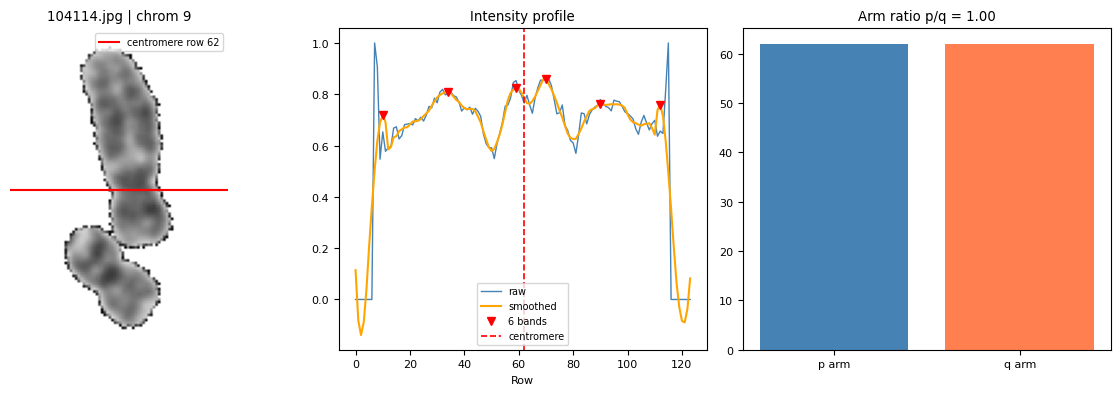

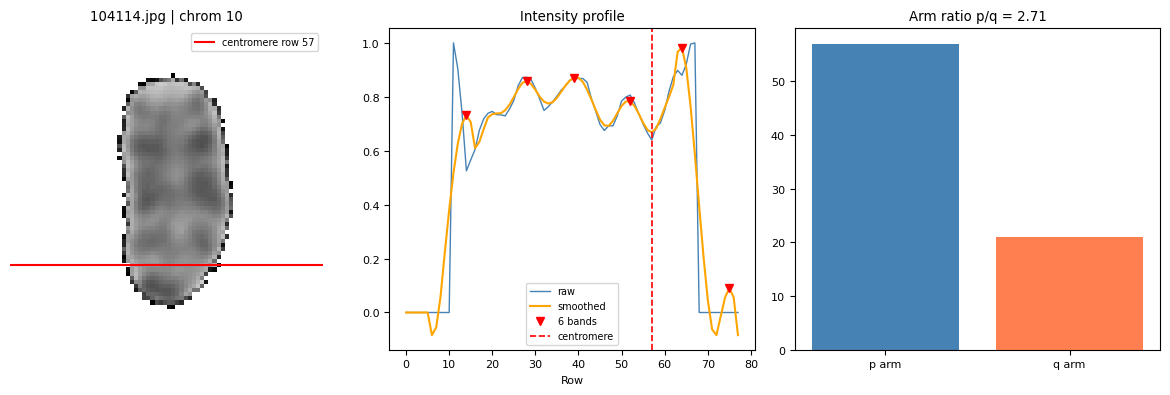

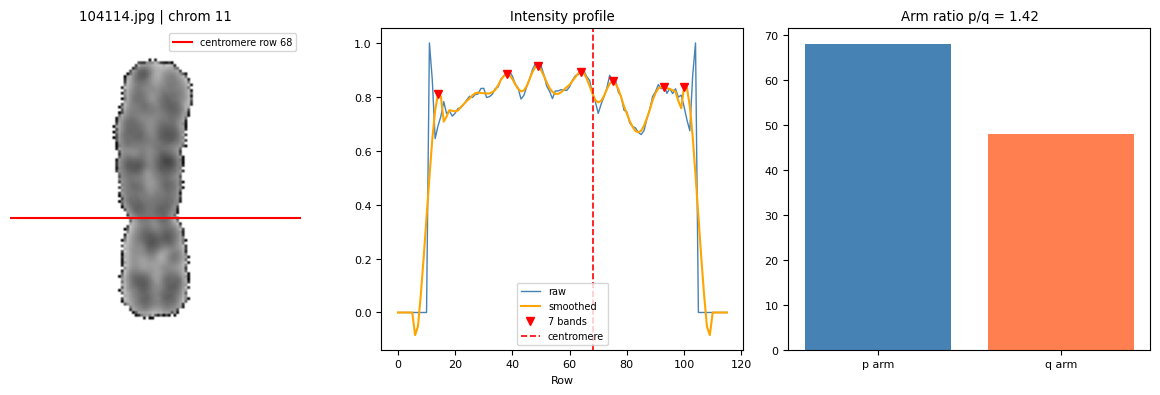

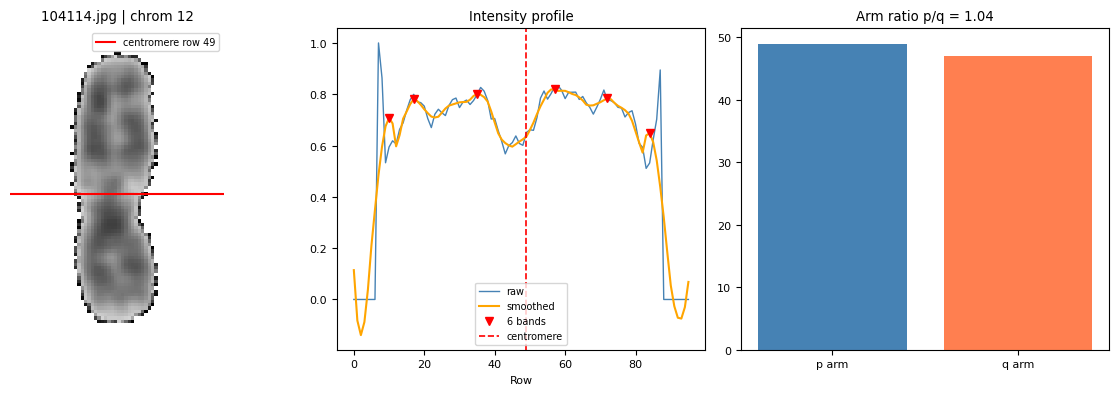

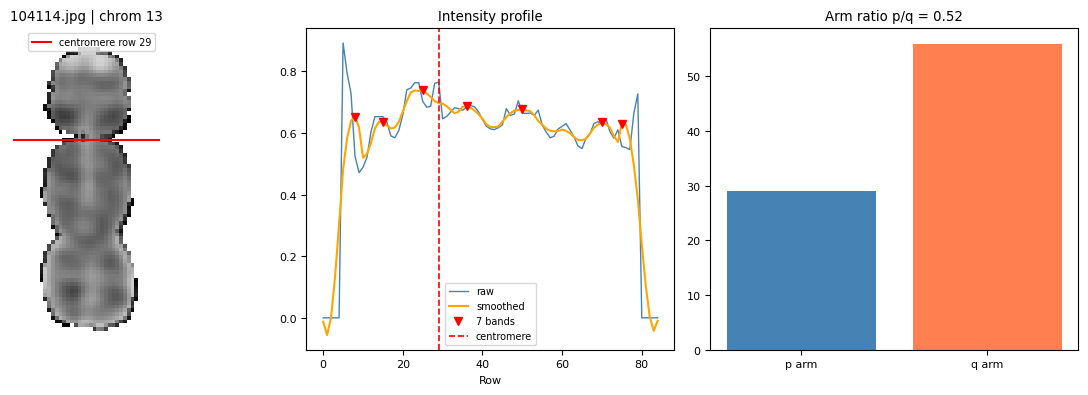

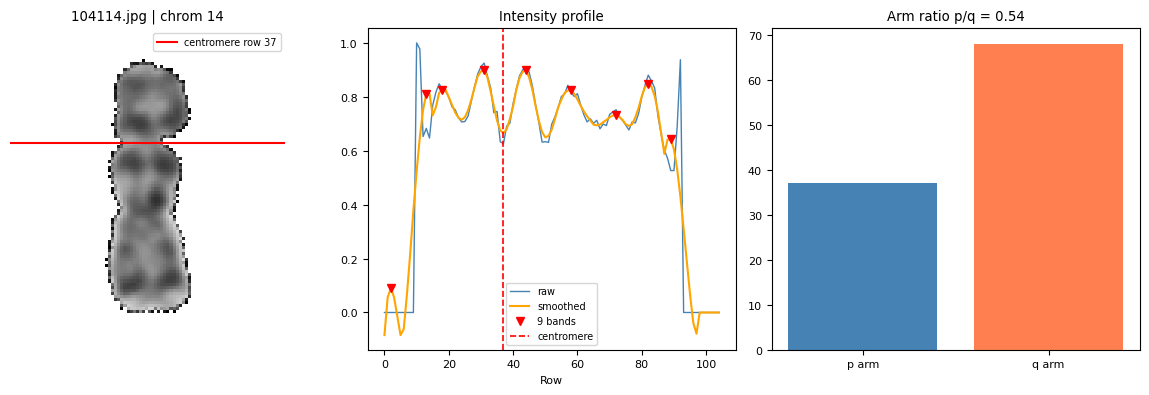

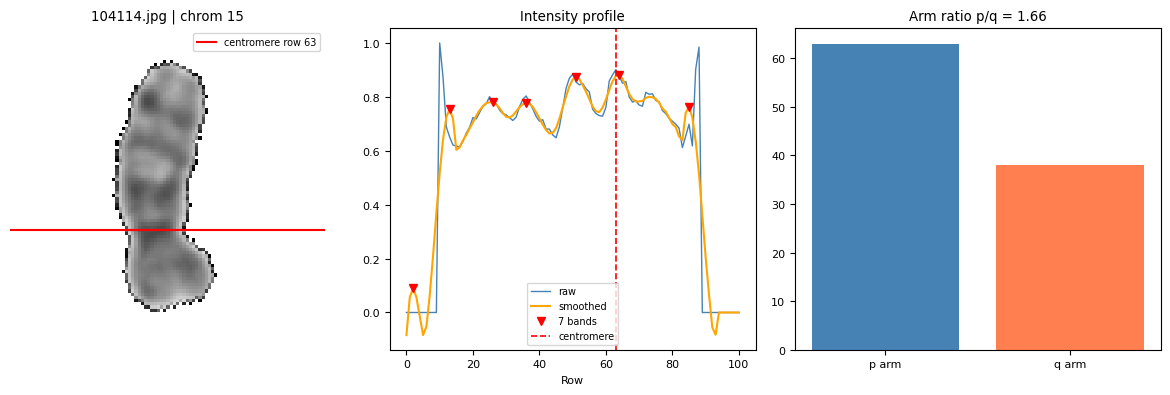

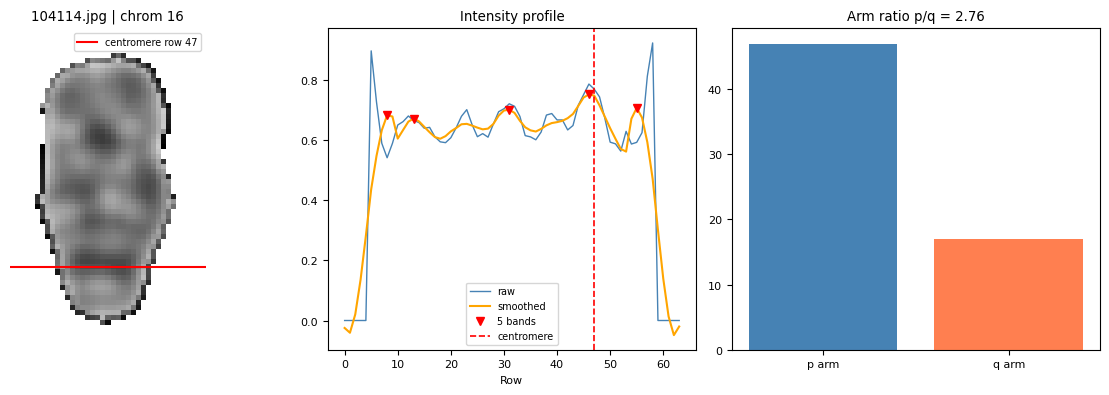

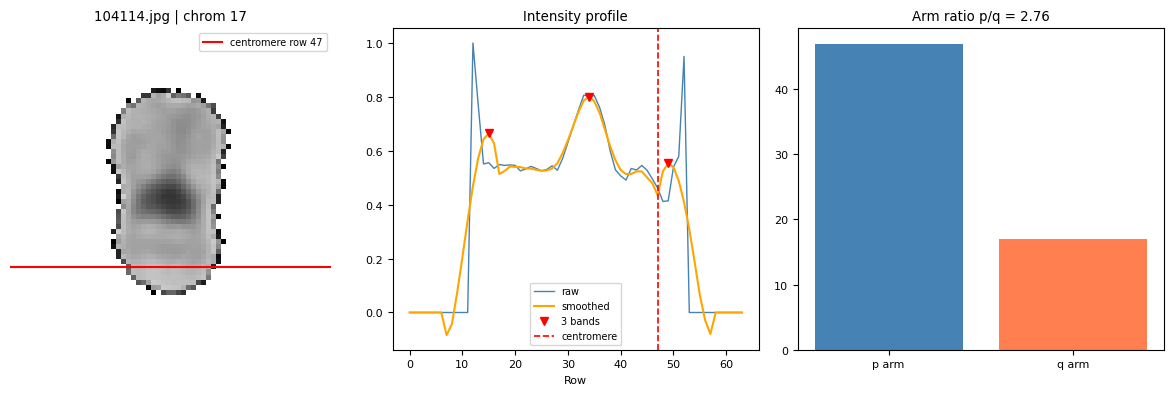

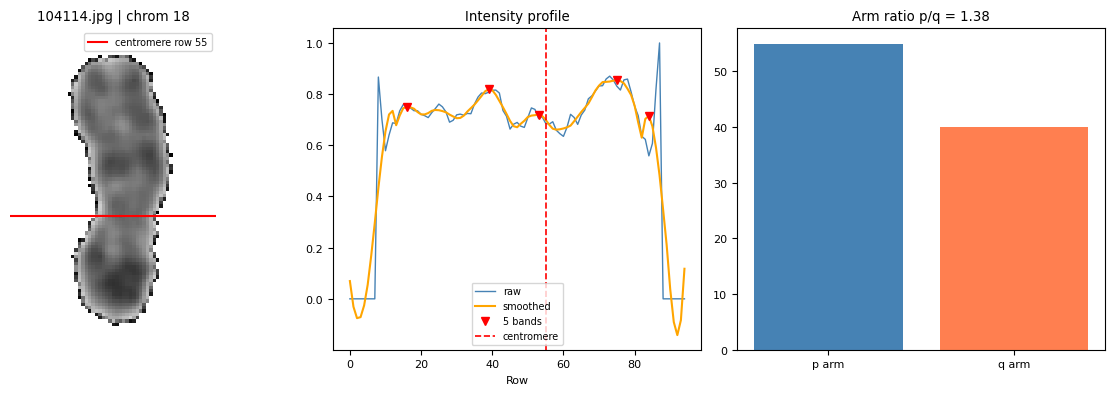

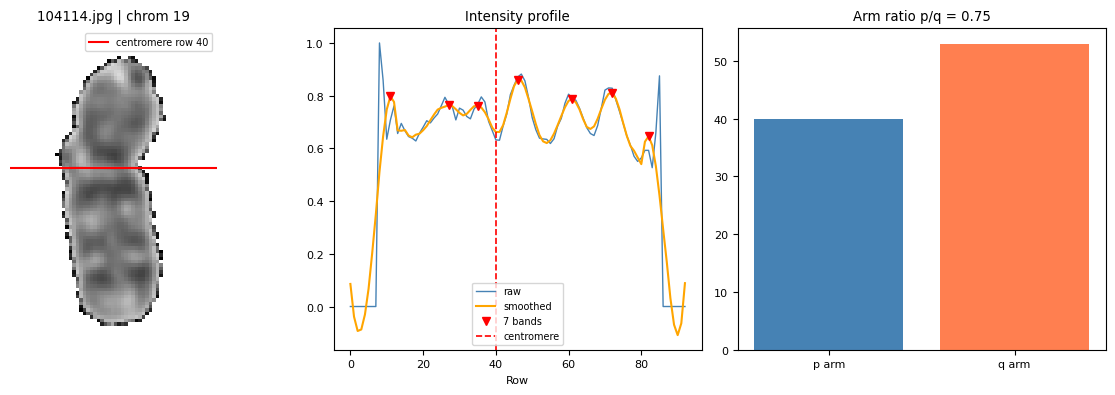

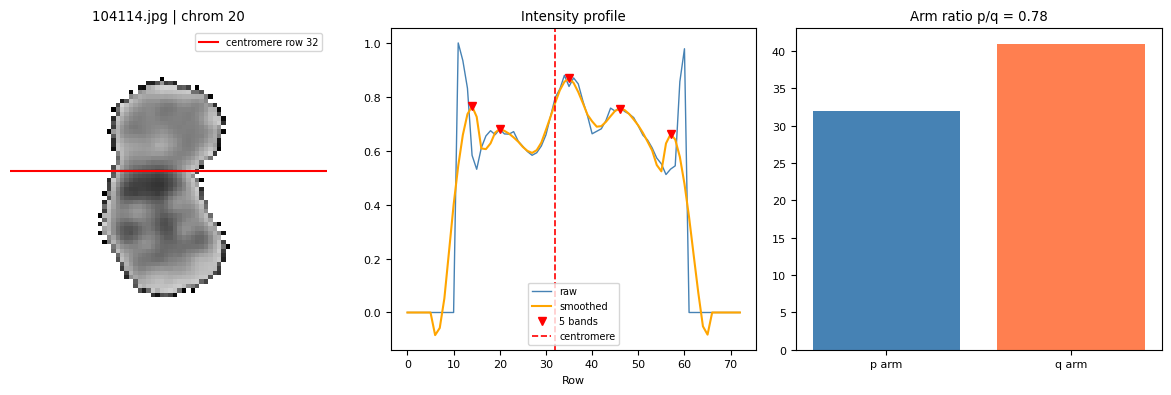

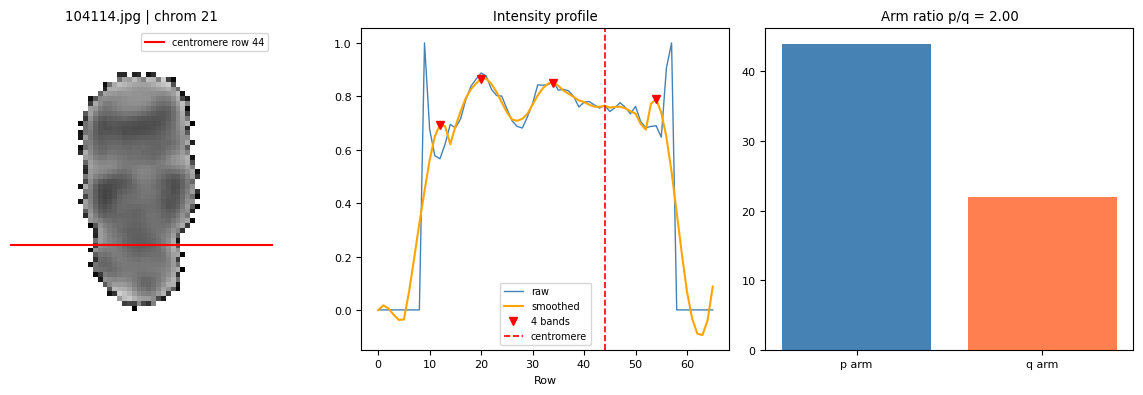

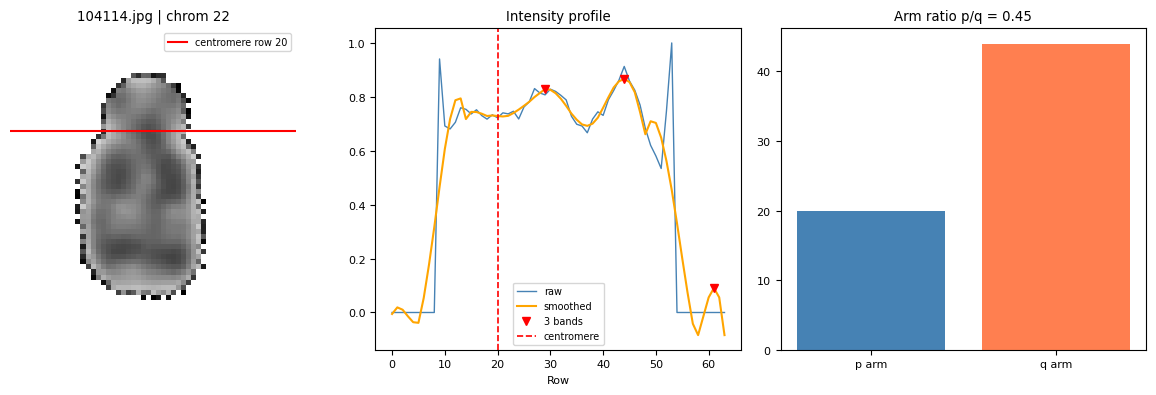

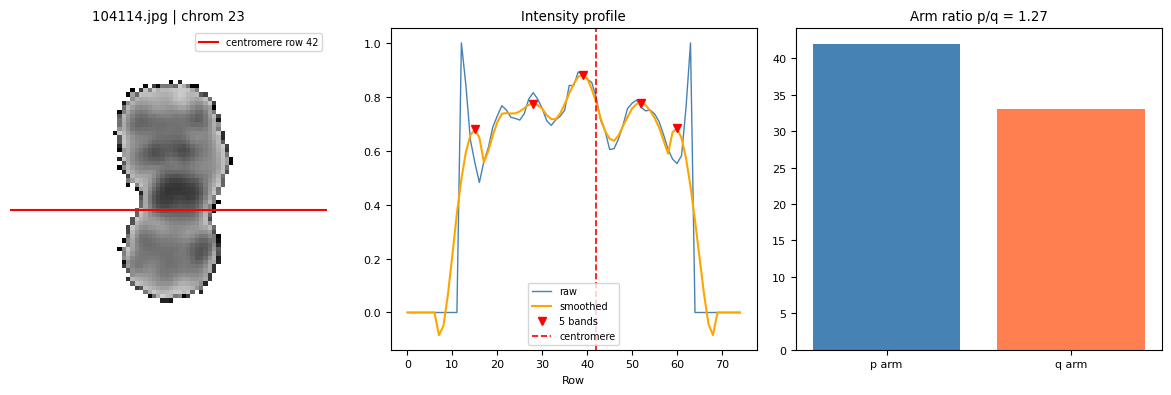

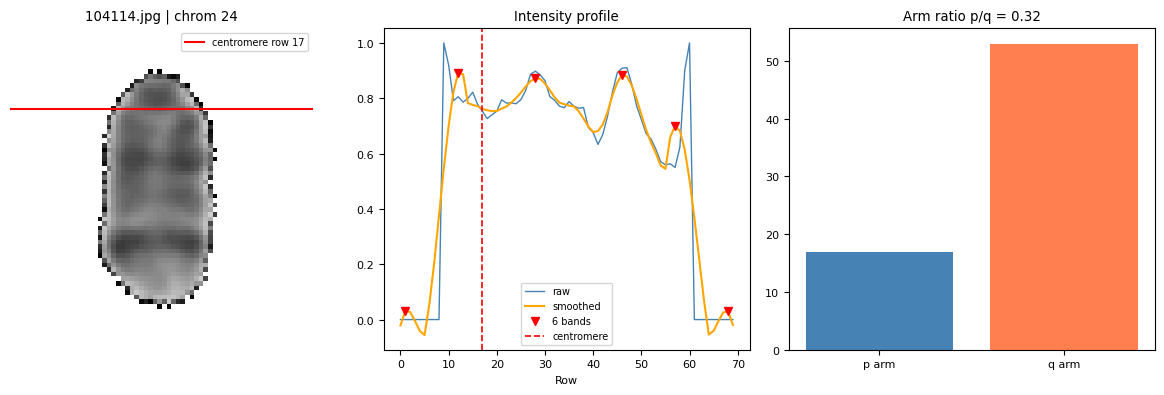

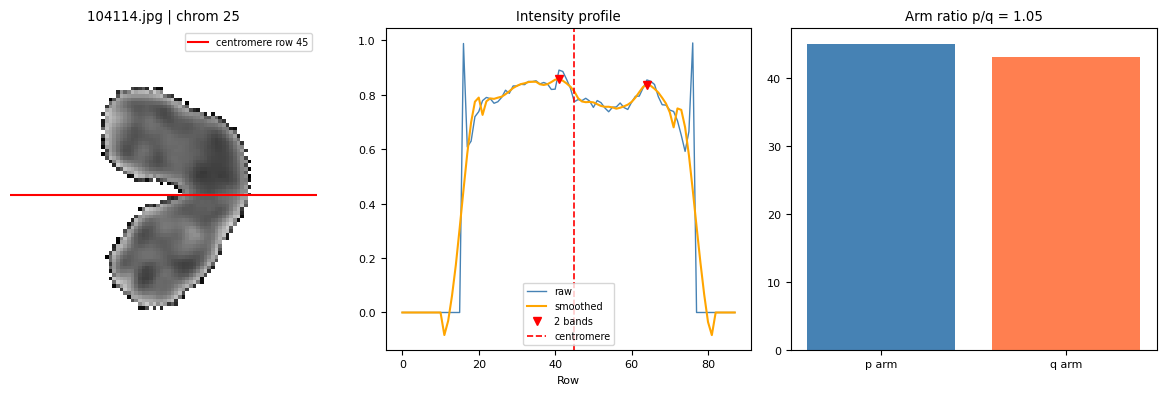

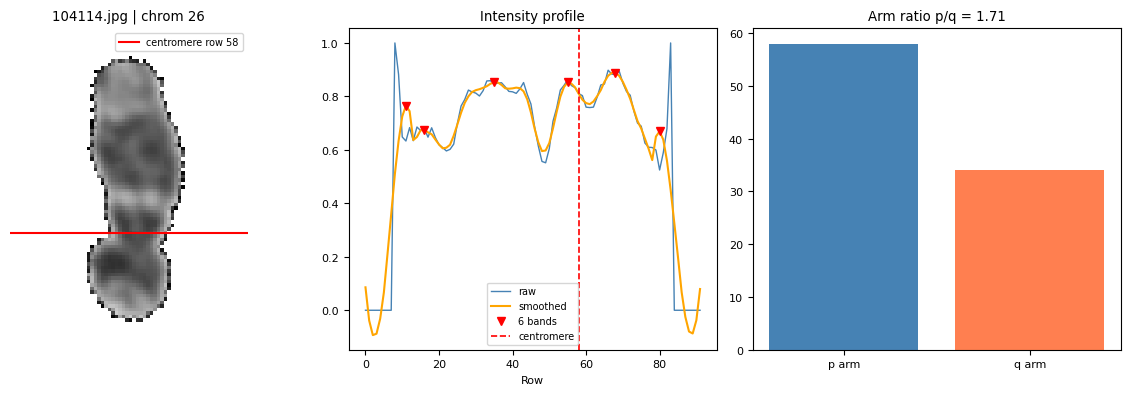

KeyboardInterrupt: 

In [131]:
centromere_positions = []
n_bands_list         = []

plot = True   # set to False to skip plots

for idx, row in df.iterrows():
    chrom = row["chrom_img"]

    # align — long axis vertical
    angle   = -row["orientation"] * 180 / np.pi
    aligned = skimage.transform.rotate(chrom, angle, resize=True, cval=0, preserve_range=True)

    # fix background: black (0) → white (1) for find_centromere and extract_intensity_profile
    aligned_white = np.where(aligned == 0, 1.0, aligned)

    # centromere
    try:
        c_pos = find_centromere(aligned_white)
        centromere_positions.append(c_pos)
    except Exception:
        c_pos = np.nan
        centromere_positions.append(np.nan)

    # bands
    try:
        profile            = extract_intensity_profile(aligned_white)
        smoothed, peaks, _ = detect_bands(profile)
        n_bands_list.append(len(peaks))
    except Exception:
        profile, smoothed, peaks = None, None, []
        n_bands_list.append(np.nan)

    if plot:
        fig, axes = plt.subplots(1, 3, figsize=(12, 4))

        # 1. aligned chromosome with centromere line
        axes[0].imshow(aligned_white, cmap='gray', vmin=0, vmax=1)
        if not np.isnan(c_pos):
            axes[0].axhline(c_pos, color='red', lw=1.5, label=f'centromere row {c_pos}')
            axes[0].legend(fontsize=7)
        axes[0].set_title(f"{row['image_name']} | chrom {row['chromosome_label']}")
        axes[0].axis('off')

        # 2. intensity profile with bands
        if profile is not None:
            axes[1].plot(profile,  color='steelblue', lw=1, label='raw')
            axes[1].plot(smoothed, color='orange',    lw=1.5, label='smoothed')
            if len(peaks):
                axes[1].plot(peaks, smoothed[peaks], 'rv', markersize=6, label=f'{len(peaks)} bands')
            if not np.isnan(c_pos):
                axes[1].axvline(c_pos, color='red', lw=1.2, linestyle='--', label='centromere')
            axes[1].set_title("Intensity profile")
            axes[1].set_xlabel("Row")
            axes[1].legend(fontsize=7)

        # 3. arm ratio info
        if not np.isnan(c_pos):
            total  = aligned_white.shape[0]
            p_arm  = c_pos
            q_arm  = total - c_pos
            ar     = p_arm / q_arm if q_arm > 0 else np.nan
            axes[2].bar(['p arm', 'q arm'], [p_arm, q_arm], color=['steelblue', 'coral'])
            axes[2].set_title(f"Arm ratio p/q = {ar:.2f}")
        else:
            axes[2].set_title("Arm ratio: centromere not detected")

        plt.tight_layout()
        plt.show()

df["centromere_position"] = centromere_positions
df["n_bands"]             = n_bands_list

In [128]:
df.head()

,image_name,chromosome_label,chrom_img,method,area,length,width,eccentricity,centroid_row,centroid_col,orientation,bbox_minr,bbox_minc,bbox_maxr,bbox_maxc,number_of_chromosomes,centromere_position,n_bands
0,104114.jpg,1,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",adaptive_histogram,689.0,43.838135,20.939931,0.878542,50.091437,502.223512,1.269776,37,482,64,524,31,44,4
1,104114.jpg,2,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",adaptive_histogram,1395.0,71.179946,25.406875,0.934128,74.059498,559.230108,0.776379,47,531,102,586,31,24,8
2,104114.jpg,3,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",adaptive_histogram,1803.0,93.189937,26.831553,0.957653,127.677759,100.795896,-0.129554,87,83,169,117,31,34,6
3,104114.jpg,4,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",adaptive_histogram,765.0,41.316117,24.160932,0.811190,103.601307,246.640523,-1.171668,88,226,117,266,31,44,5
4,104114.jpg,5,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",adaptive_histogram,629.0,34.065202,23.879827,0.713158,125.464229,198.483307,-1.058411,111,183,141,216,31,14,4
